# Exploratory Data Analysis: Tecnoempleo Data Jobs

Este notebook analiza ofertas de empleo relacionadas con datos a partir del archivo `tecnoempleo_jobs_enriched.csv`. La estructura sigue como guía el enfoque del notebook `EDATalent`: carga de datos, revisión inicial, limpieza ligera, creación de variables y visualizaciones para entender el mercado laboral.

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Configure Pandas display options for a clearer notebook output.
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

# Configure a consistent visual style for all charts.
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

**Observación:** Se importan las herramientas necesarias para el análisis tabular y la visualización. Se usa `matplotlib` porque está disponible en el entorno y permite crear todos los gráficos necesarios sin depender de librerías extra.

In [2]:
# Load the dataset using a robust path for both the project root and the EDATalent folder.
root_data_path = Path("EDATalent") / "tecnoempleo_jobs_enriched.csv"
local_data_path = Path("tecnoempleo_jobs_enriched.csv")
data_path = root_data_path if root_data_path.exists() else local_data_path

df = pd.read_csv(data_path)

# Show the first rows to understand the available fields.
df.head()

,Category,No,Title,Company,Location,Publication Date,Technology Stack,Salary,Experience,Contract Type,URL,Description
0,Big Data,1,Ingeniero/a de Integración y Datos,CAS TRAINING,100% remoto,29/05/2026,"JSONmXML, AWS, Python",Not specified,5+ years,Permanent,https://www.tecnoempleo.com/ingeniero-integracion-datos-cas-training/jsonmxml-aws/rf-50111dd1528033e61d4a,"🎯Buscamos un/a Integration & Data Engineer Mid-Level con enfoque en integraciones, mensajería y procesamiento de dat..."
1,Big Data,2,Data engineer (AWS/OCR/PYTHON),Grupo NS,100% remoto,29/05/2026,"python, AWS, Pandas",Not specified,3+ years,Permanent,https://www.tecnoempleo.com/data-engineer-aws-ocr-python-grupo-ns/pandas-numpy/rf-abd11045522ea371354d,"Desde Grupo NS precisamos incorporar un data engineer con al menos 3 años de experiencia, para un proyecto de larga ..."
2,Big Data,3,Data & AI Strategy Enterprise AI Architect,Accenture,Barcelona,29/05/2026,"Python, SQL, AWS",Not specified,6+ years,Permanent,https://www.tecnoempleo.com/data-ai-strategy-enterprise-ai-architect-accenture/python-sql/rf-d9cc169ce2d213eca146,"Are you ready to design and scale the Data & AI backbone of next-generation intelligent enterprises? At Accenture, w..."
3,Big Data,4,Analista de datos Python - Sector Banca,Accenture,Madrid,29/05/2026,"Python, SQL, Spark",Not specified,5+ years,Permanent,https://www.tecnoempleo.com/analista-datos-python-sector-banca-accenture/sql-spark/rf-120f1b8f4229c3036049,Transformamos las operaciones de nuestros clientes a través de la tecnología y los datos gracias a un equipo de más ...
4,Big Data,5,BI Developer (WebFOCUS),Digital Talent Agency,100% remoto,29/05/2026,"webfocus, BI, SQL",Not specified,Not specified,Permanent,https://www.tecnoempleo.com/bi-developer-webfocus-digital-talent-agency/sql/rf-80ec11f2320623d9b144,Buscamos un/a BI Developer especializado/a en WebFOCUS para incorporarse a un proyecto de consultoría en entorno int...


**Observación:** La carga inicial permite confirmar que el dataset contiene ofertas de empleo con categoría, empresa, ubicación, fecha, stack tecnológico, salario, experiencia, tipo de contrato, URL y descripción.

In [3]:
# Review the dataset size and the column names.
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print("\nColumn names:")
print(df.columns.tolist())

Rows: 93
Columns: 12

Column names:
['Category', 'No', 'Title', 'Company', 'Location', 'Publication Date', 'Technology Stack', 'Salary', 'Experience', 'Contract Type', 'URL', 'Description']


**Observación:** Esta celda dimensiona el alcance del análisis. Antes de interpretar patrones del mercado laboral, conviene saber cuántas ofertas y variables reales tenemos.

In [4]:
# Inspect data types and non-null values.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Category          93 non-null     str  
 1   No                93 non-null     int64
 2   Title             93 non-null     str  
 3   Company           93 non-null     str  
 4   Location          93 non-null     str  
 5   Publication Date  93 non-null     str  
 6   Technology Stack  93 non-null     str  
 7   Salary            93 non-null     str  
 8   Experience        93 non-null     str  
 9   Contract Type     93 non-null     str  
 10  URL               93 non-null     str  
 11  Description       93 non-null     str  
dtypes: int64(1), str(11)
memory usage: 8.8 KB


**Observación:** La revisión con `info()` sirve para validar si hay valores nulos y qué columnas necesitan transformación, por ejemplo fechas, experiencia o salario.

In [5]:
# Check missing values and duplicated job links.
missing_values = df.isna().sum().sort_values(ascending=False)
duplicated_urls = df.duplicated(subset="URL").sum()
duplicated_title_company = df.duplicated(subset=["Title", "Company"]).sum()

print("Missing values by column:")
print(missing_values)
print(f"\nDuplicated URLs: {duplicated_urls}")
print(f"Duplicated title-company pairs: {duplicated_title_company}")

Missing values by column:
Category            0
No                  0
Title               0
Company             0
Location            0
Publication Date    0
Technology Stack    0
Salary              0
Experience          0
Contract Type       0
URL                 0
Description         0
dtype: int64

Duplicated URLs: 0
Duplicated title-company pairs: 2


**Observación:** La calidad del dataset es una parte clave del EDA. Si no hay URLs duplicadas, cada fila puede tratarse como una oferta única; los posibles duplicados por título y empresa se revisan solo como señal de repetición comercial.

In [6]:
# Create derived fields for dates, remote work, experience, and salary availability.
df_clean = df.copy()

df_clean["Publication Date"] = pd.to_datetime(
    df_clean["Publication Date"],
    format="%d/%m/%Y",
    errors="coerce"
)
df_clean["Is Remote"] = df_clean["Location"].str.contains("remoto", case=False, na=False)
df_clean["Salary Specified"] = ~df_clean["Salary"].str.contains("Not specified", case=False, na=False)
df_clean["Required Years"] = (
    df_clean["Experience"]
    .str.extract(r"(\d+)")
    .astype(float)
)

df_clean[["Publication Date", "Location", "Is Remote", "Experience", "Required Years", "Salary", "Salary Specified"]].head()

,Publication Date,Location,Is Remote,Experience,Required Years,Salary,Salary Specified
0,2026-05-29,100% remoto,True,5+ years,5.00,Not specified,False
1,2026-05-29,100% remoto,True,3+ years,3.00,Not specified,False
2,2026-05-29,Barcelona,False,6+ years,6.00,Not specified,False
3,2026-05-29,Madrid,False,5+ years,5.00,Not specified,False
4,2026-05-29,100% remoto,True,Not specified,NaN,Not specified,False


**Observación:** Aquí se crean variables útiles para responder preguntas de negocio: cuándo se publicó la oferta, si es remota, cuántos años exige y si informa salario. Estas columnas facilitan gráficos y comparaciones posteriores.

In [7]:
# Summarize the most important categorical variables.
categorical_summary = {
    "Category": df_clean["Category"].nunique(),
    "Company": df_clean["Company"].nunique(),
    "Location": df_clean["Location"].nunique(),
    "Contract Type": df_clean["Contract Type"].nunique(),
}

pd.Series(categorical_summary, name="Unique values")

Category          4
Company          37
Location         14
Contract Type     2
Name: Unique values, dtype: int64

**Observación:** Este resumen indica la variedad del mercado observado: cuántas categorías, empresas, ubicaciones y tipos de contrato aparecen en la muestra.

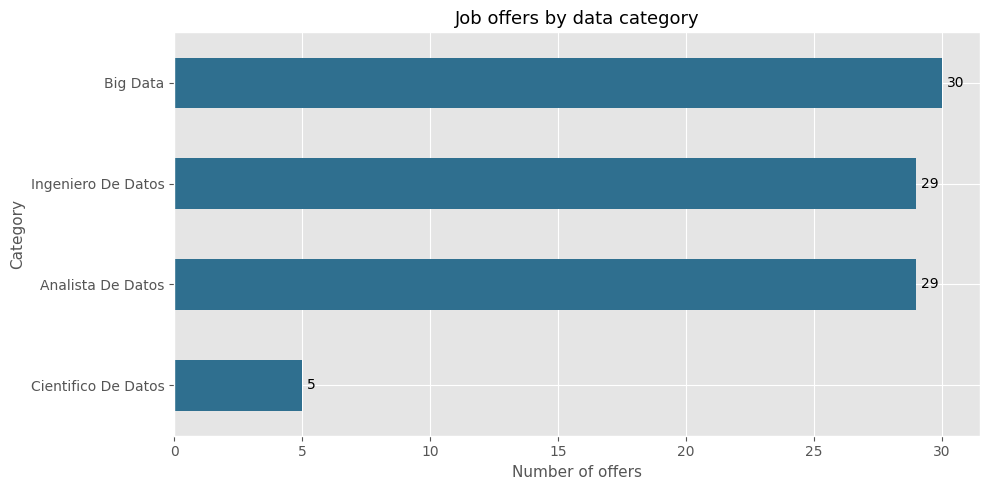

In [8]:
# Plot the number of jobs by data category.
category_counts = df_clean["Category"].value_counts().sort_values()

ax = category_counts.plot(kind="barh", color="#2f6f8f")
ax.set_title("Job offers by data category")
ax.set_xlabel("Number of offers")
ax.set_ylabel("Category")

for index, value in enumerate(category_counts):
    ax.text(value + 0.2, index, str(value), va="center")

plt.tight_layout()
plt.show()

**Observación:** Este gráfico muestra qué perfiles de datos concentran más demanda en el dataset. Sirve para detectar si el mercado observado está más orientado a ingeniería, análisis, big data o ciencia de datos.

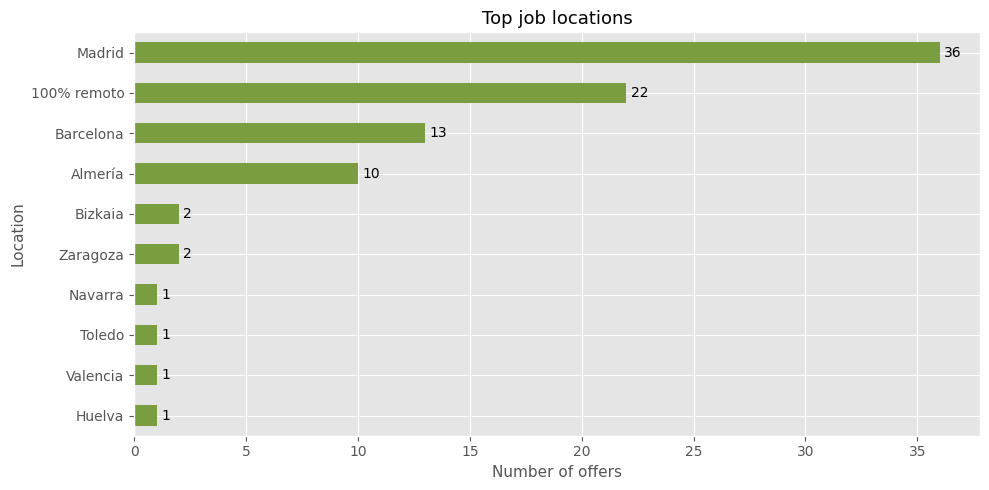

In [9]:
# Plot the most frequent job locations.
top_locations = df_clean["Location"].value_counts().head(10).sort_values()

ax = top_locations.plot(kind="barh", color="#7a9e3f")
ax.set_title("Top job locations")
ax.set_xlabel("Number of offers")
ax.set_ylabel("Location")

for index, value in enumerate(top_locations):
    ax.text(value + 0.2, index, str(value), va="center")

plt.tight_layout()
plt.show()

**Observación:** La ubicación ayuda a distinguir concentración territorial y peso del trabajo remoto. En un análisis de empleabilidad, esta señal es importante porque afecta accesibilidad y oportunidades para candidatos fuera de grandes ciudades.

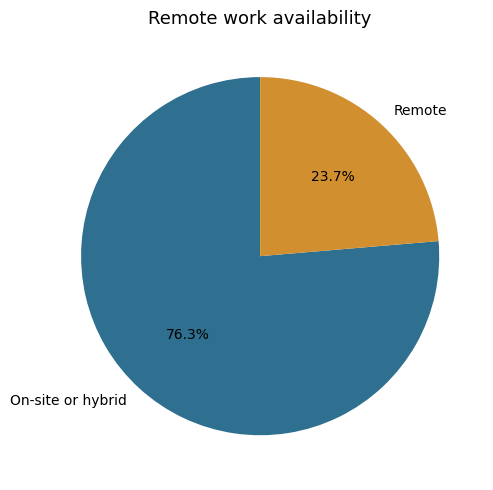

In [10]:
# Compare remote and non-remote offers.
remote_counts = df_clean["Is Remote"].map({True: "Remote", False: "On-site or hybrid"}).value_counts()

ax = remote_counts.plot(kind="pie", autopct="%1.1f%%", startangle=90, colors=["#2f6f8f", "#d18f2f"])
ax.set_title("Remote work availability")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

**Observación:** El porcentaje de ofertas remotas permite evaluar flexibilidad laboral. Esta variable es especialmente relevante para comparar oportunidades más accesibles frente a ofertas que dependen de una ciudad concreta.

In [11]:
# Analyze required years of experience by category.
experience_by_category = (
    df_clean
    .dropna(subset=["Required Years"])
    .groupby("Category")["Required Years"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

experience_by_category

,count,mean,median,min,max
Category,,,,,
Analista De Datos,12,5.42,4.00,2.00,25.00
Ingeniero De Datos,13,3.92,4.00,2.00,6.00
Cientifico De Datos,3,3.67,3.00,3.00,5.00
Big Data,14,3.50,3.00,1.00,6.00


**Observación:** Esta tabla resume la seniority pedida por categoría. La media y mediana ayudan a ver si algunas familias de puestos exigen más experiencia que otras.

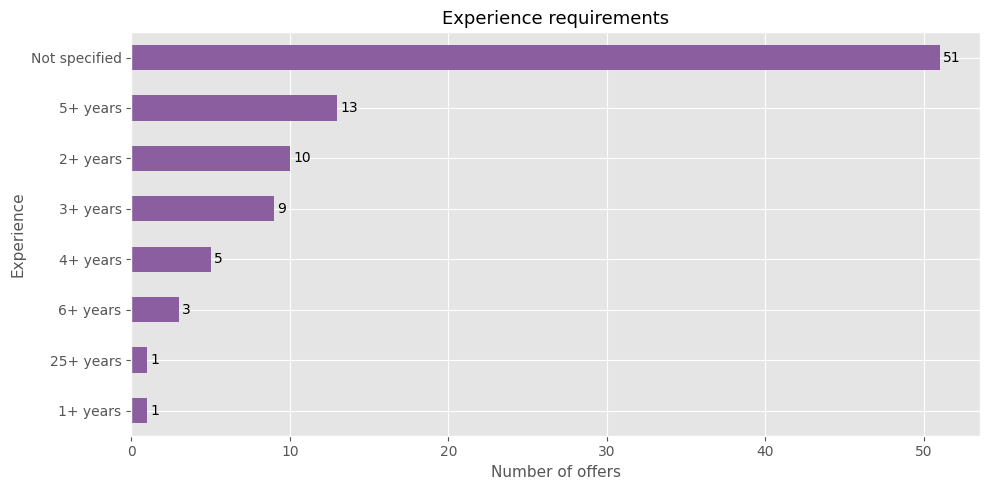

In [12]:
# Plot the distribution of required experience values.
experience_counts = df_clean["Experience"].value_counts().sort_values()

ax = experience_counts.plot(kind="barh", color="#8b5f9f")
ax.set_title("Experience requirements")
ax.set_xlabel("Number of offers")
ax.set_ylabel("Experience")

for index, value in enumerate(experience_counts):
    ax.text(value + 0.2, index, str(value), va="center")

plt.tight_layout()
plt.show()

**Observación:** La experiencia no siempre está especificada, por eso conviene visualizar también las etiquetas originales. Esto evita ocultar la proporción de ofertas que no comunican claramente su nivel esperado.

In [13]:
# Extract salary ranges when they are available.
def extract_salary_values(salary_text):
    """Return minimum, maximum, and midpoint salary values from a salary string."""
    if pd.isna(salary_text) or "not specified" in salary_text.lower():
        return pd.Series([np.nan, np.nan, np.nan])

    values = [int(value.replace(".", "")) for value in re.findall(r"\d{2}\.\d{3}", salary_text)]
    if len(values) == 1:
        return pd.Series([values[0], values[0], values[0]])
    if len(values) >= 2:
        minimum, maximum = values[0], values[1]
        return pd.Series([minimum, maximum, (minimum + maximum) / 2])

    return pd.Series([np.nan, np.nan, np.nan])

df_clean[["Salary Min", "Salary Max", "Salary Midpoint"]] = df_clean["Salary"].apply(extract_salary_values)

df_clean.loc[df_clean["Salary Specified"], ["Title", "Category", "Salary", "Salary Min", "Salary Max", "Salary Midpoint"]].head()

,Title,Category,Salary,Salary Min,Salary Max,Salary Midpoint
5,Ingeniero/a Gobierno del Dato e IA,Big Data,33.000€ - 42.000€ b/a,"33,000.00","42,000.00","37,500.00"
6,Data Engineer,Big Data,30.000€ - 36.000€ b/a,"30,000.00","36,000.00","33,000.00"
9,Data Engineer,Big Data,45.000€ - 76.000€ b/a,"45,000.00","76,000.00","60,500.00"
23,Data Engineer / Backend Developer,Big Data,39.000€ - 45.000€ b/a,"39,000.00","45,000.00","42,000.00"
25,Data Analyst (Sector Automocion),Big Data,30.000€ - 33.000€ b/a,"30,000.00","33,000.00","31,500.00"


**Observación:** Muchas ofertas no publican salario, así que esta transformación solo convierte rangos cuando existen. El punto medio permite comparar salarios de forma aproximada sin perder el rango original.

In [14]:
# Summarize salary availability and salary midpoint statistics.
salary_summary = df_clean["Salary Specified"].value_counts().rename(index={True: "Specified", False: "Not specified"})
salary_stats = df_clean["Salary Midpoint"].describe()

print("Salary availability:")
print(salary_summary)
print("\nSalary midpoint statistics:")
print(salary_stats)

Salary availability:
Salary Specified
Not specified    75
Specified        18
Name: count, dtype: int64

Salary midpoint statistics:
count       18.00
mean    41,305.56
std     12,779.97
min     25,500.00
25%     33,375.00
50%     36,750.00
75%     42,000.00
max     66,000.00
Name: Salary Midpoint, dtype: float64


**Observación:** Separar disponibilidad salarial de estadística salarial evita conclusiones engañosas. Si pocas ofertas informan salario, cualquier lectura económica debe tratarse como exploratoria.

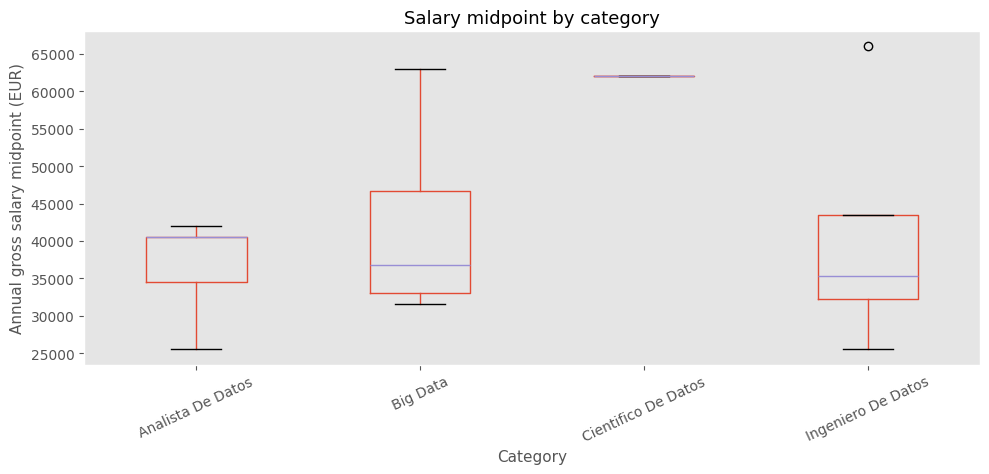

In [15]:
# Plot salary midpoints by category for offers with salary information.
salary_data = df_clean.dropna(subset=["Salary Midpoint"])

if salary_data.empty:
    print("No salary data available for plotting.")
else:
    ax = salary_data.boxplot(column="Salary Midpoint", by="Category", grid=False, rot=25)
    ax.set_title("Salary midpoint by category")
    ax.set_xlabel("Category")
    ax.set_ylabel("Annual gross salary midpoint (EUR)")
    plt.suptitle("")
    plt.tight_layout()
    plt.show()

**Observación:** El boxplot permite comparar rangos salariales entre categorías, aunque debe leerse con cautela porque solo incluye ofertas que sí publican salario.

In [16]:
# Split the technology stack field and count the most frequent technologies.
tech_series = (
    df_clean["Technology Stack"]
    .str.split(",")
    .explode()
    .str.strip()
    .str.lower()
)
tech_series = tech_series[tech_series.ne("") & tech_series.notna()]
top_technologies = tech_series.value_counts().head(15)

top_technologies

Technology Stack
python      25
sql         23
java        12
etl         10
aws          8
data         6
power bi     5
excel        5
ci/cd        4
azure        4
r            4
spark        3
scala        3
pyspark      3
spring       3
Name: count, dtype: int64

**Observación:** La columna de stack tecnológico es central para la problemática del proyecto, porque permite identificar qué herramientas y lenguajes aparecen con más frecuencia en las ofertas de datos.

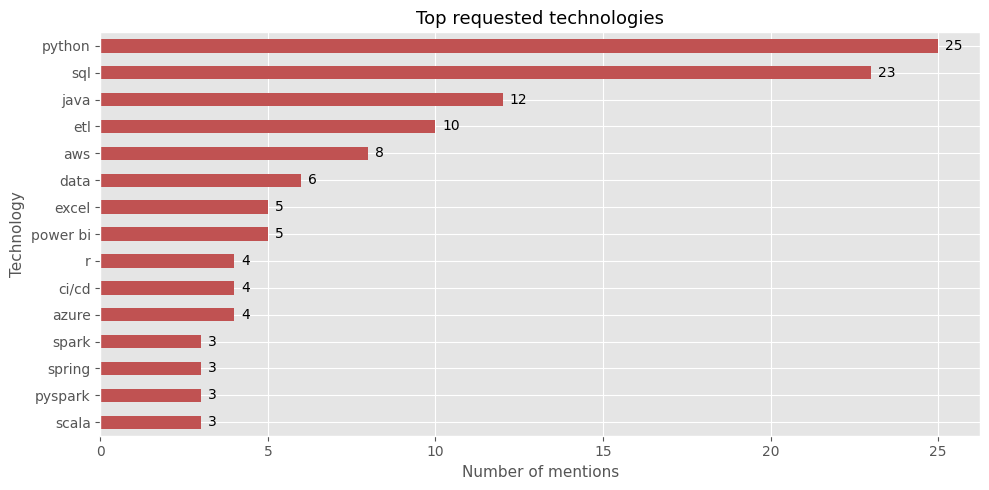

In [17]:
# Plot the most requested technologies.
ax = top_technologies.sort_values().plot(kind="barh", color="#c05252")
ax.set_title("Top requested technologies")
ax.set_xlabel("Number of mentions")
ax.set_ylabel("Technology")

for index, value in enumerate(top_technologies.sort_values()):
    ax.text(value + 0.2, index, str(value), va="center")

plt.tight_layout()
plt.show()

**Observación:** Este gráfico traduce el texto del stack en una lectura accionable: las tecnologías con más menciones pueden orientar prioridades de aprendizaje o especialización profesional.

In [18]:
# Build a category versus remote-work table.
category_remote_table = pd.crosstab(
    df_clean["Category"],
    df_clean["Is Remote"].map({True: "Remote", False: "On-site or hybrid"}),
    normalize="index"
) * 100

category_remote_table.round(1)

Is Remote,On-site or hybrid,Remote
Category,,
Analista De Datos,62.10,37.90
Big Data,73.30,26.70
Cientifico De Datos,80.00,20.00
Ingeniero De Datos,93.10,6.90


**Observación:** Esta tabla compara la flexibilidad por categoría. Usar porcentajes por fila permite ver la proporción remota dentro de cada tipo de perfil, no solo el volumen total.

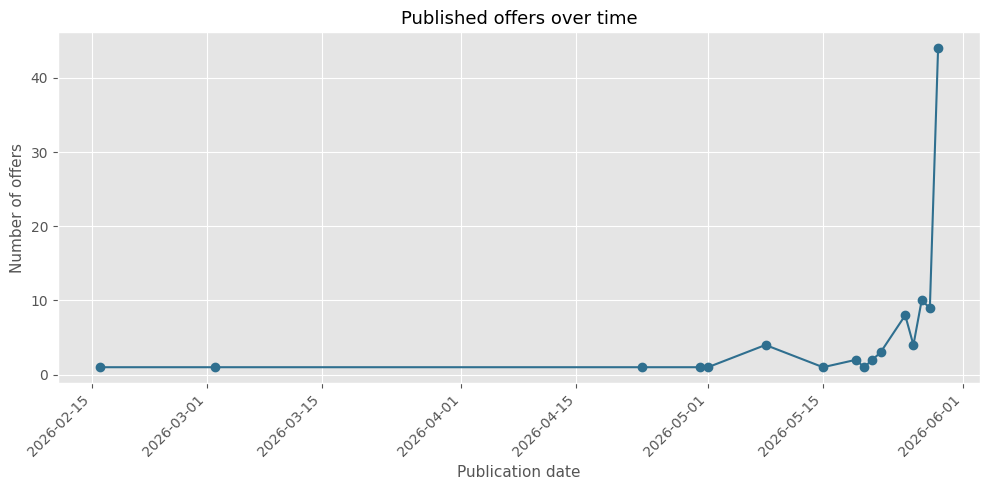

In [19]:
# Plot the number of published offers over time.
offers_by_date = df_clean["Publication Date"].value_counts().sort_index()

ax = offers_by_date.plot(kind="line", marker="o", color="#2f6f8f")
ax.set_title("Published offers over time")
ax.set_xlabel("Publication date")
ax.set_ylabel("Number of offers")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observación:** La evolución temporal ayuda a ver si las ofertas están concentradas en pocos días o distribuidas en el periodo capturado. Esto también da contexto sobre la actualidad de la muestra.

In [20]:
# Create a compact final summary with key EDA indicators.
summary = pd.Series({
    "Total offers": len(df_clean),
    "Unique companies": df_clean["Company"].nunique(),
    "Unique locations": df_clean["Location"].nunique(),
    "Remote offers": int(df_clean["Is Remote"].sum()),
    "Salary specified offers": int(df_clean["Salary Specified"].sum()),
    "Most common category": df_clean["Category"].mode().iloc[0],
    "Most common technology": top_technologies.index[0],
    "Most common location": df_clean["Location"].mode().iloc[0],
})

summary

Total offers                     93
Unique companies                 37
Unique locations                 14
Remote offers                    22
Salary specified offers          18
Most common category       Big Data
Most common technology       python
Most common location         Madrid
dtype: object

**Observación:** El resumen final consolida los hallazgos principales del EDA: volumen de ofertas, empresas, ubicaciones, remoto, salarios publicados, categoría dominante y tecnología más repetida. Es una base clara para una conclusión posterior o para profundizar en nuevas preguntas.